# Lesson 2: Integrated Gradients on a tiny neural network

In Lesson 1 our "model" was a hand-written function $f(x)=x_0 x_1+\sin x_2$, so
we could check IG by hand. **The one thing missing was an actual neural network.**

This lesson adds the *smallest* complication that makes it real:

1. **A trained network**, not a formula — a 2-layer MLP with a ReLU hidden
   layer and a sigmoid output.
2. **A problem that forces the network to exist: XOR.** The label is 1 when the
   two inputs have the *same sign* (both +, or both −). This is the classic
   *not-linearly-separable* problem — no single straight line separates the
   classes, so a linear model is hopeless and a hidden layer is mandatory.
3. **The real reason IG exists: saturation.** At a confidently classified point
   the sigmoid flattens out, so the plain gradient collapses to ~0 and falsely
   reports "no input matters." IG integrates from a baseline and recovers the
   true story.

The IG code itself is *identical* to Lesson 1 — that's the point. IG treats the
network as a black box `inputs -> output`; it doesn't care what's inside.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Nonlinear, saturating models need a finer Riemann sum than Lesson 1's smooth
# function. We saw 64 steps leave a ~0.10 completeness error here; 256 fixes it.
N_STEPS = 256

## Step 1 — Make the XOR dataset

Points live in the 2D square $[-3, 3]^2$. Label $=1$ when $x_0$ and $x_1$ have
the **same sign** (top-right and bottom-left quadrants), else $0$.

Notice the diagonal pattern below: no straight line can separate red from blue.
That's exactly why we need a network with a hidden layer.

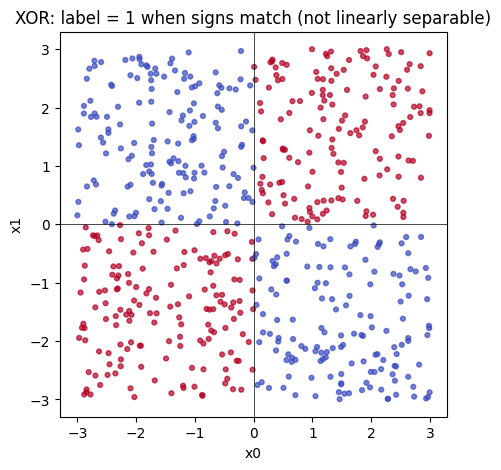

In [2]:
N = 600
X = torch.rand(N, 2) * 6 - 3                       # uniform in [-3, 3]^2
y = ((X[:, 0] > 0) == (X[:, 1] > 0)).float()       # XOR: same-sign -> 1

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12, alpha=0.7)
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("x0"); plt.ylabel("x1")
plt.title("XOR: label = 1 when signs match (not linearly separable)")
plt.show()

## Step 2 — Define and train the tiny MLP

Architecture: `Linear(2 -> 16) -> ReLU -> Linear(16 -> 1)`. The final layer
outputs a single **logit**; a sigmoid turns it into the probability of class 1.

We train with `BCEWithLogitsLoss` (numerically stable sigmoid + cross-entropy)
for a few hundred steps — a second or two on CPU.

In [3]:
net = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

opt = torch.optim.Adam(net.parameters(), lr=0.05)
loss_fn = nn.BCEWithLogitsLoss()

for epoch in range(800):
    opt.zero_grad()
    logits = net(X).squeeze(1)
    loss = loss_fn(logits, y)
    loss.backward()
    opt.step()
    if epoch % 200 == 0 or epoch == 799:
        acc = ((torch.sigmoid(logits) > 0.5).float() == y).float().mean()
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}  train acc {acc.item():.3f}")

epoch    0  loss 0.7316  train acc 0.512
epoch  200  loss 0.0160  train acc 1.000
epoch  400  loss 0.0076  train acc 1.000


epoch  600  loss 0.0047  train acc 1.000
epoch  799  loss 0.0034  train acc 1.000


Let's look at what the network learned. The contour shows $P(\text{class }1)$
across the plane — you should see the four-quadrant XOR pattern, which a linear
model could never produce.

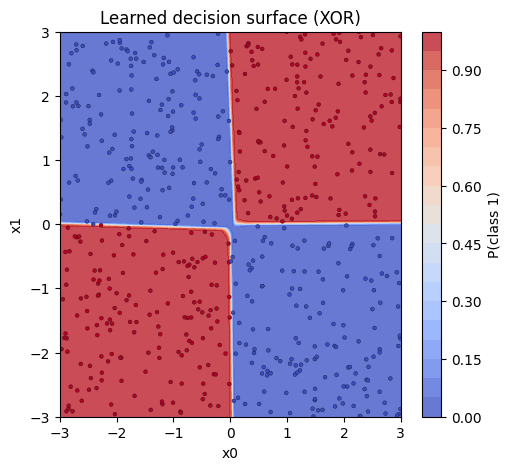

In [4]:
# Probability surface over a grid.
g = torch.linspace(-3, 3, 200)
gx, gy = torch.meshgrid(g, g, indexing="xy")
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=1)
with torch.no_grad():
    prob = torch.sigmoid(net(grid)).reshape(200, 200)

plt.figure(figsize=(5.5, 5))
plt.contourf(gx, gy, prob, levels=20, cmap="coolwarm", alpha=0.8)
plt.colorbar(label="P(class 1)")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=8, edgecolors="k", linewidths=0.2)
plt.xlabel("x0"); plt.ylabel("x1")
plt.title("Learned decision surface (XOR)")
plt.show()

## Step 3 — Wrap the network as a scalar function `f(x) -> probability`

IG attributes a single scalar output. We explain the **probability of class 1**,
so our `f` is `sigmoid(net(x))`. This wrapper is the only IG-specific glue.

In [5]:
def f(x):
    """x: (batch, 2) -> (batch,) probability of class 1."""
    return torch.sigmoid(net(x).squeeze(1))

## Step 4 — The IG function (unchanged from Lesson 1)

Copy-paste. It never mentions the network — `model` is just a callable.
(We additionally return the path and gradients so we can plot them later.)

In [6]:
def integrated_gradients(model, x, baseline, n_steps=N_STEPS):
    alphas = (torch.arange(n_steps, dtype=torch.float32) + 0.5) / n_steps
    delta = x - baseline
    path = baseline.unsqueeze(0) + alphas.unsqueeze(1) * delta.unsqueeze(0)
    path.requires_grad_(True)

    outputs = model(path)
    outputs.sum().backward()
    grads = path.grad

    avg_grads = grads.mean(dim=0)
    return (delta * avg_grads).detach(), path.detach(), grads.detach()

## Step 5 — Choose a point to explain, and a baseline

We explain a **confident class-1 point**, $x = [2.5, 2.5]$ (both positive →
same sign → class 1, predicted with very high probability).

For the baseline we use the conventional **all-inputs-off** reference,
$x'=[0,0]$ — the standard zero baseline, meaning "no signal present." IG always
explains the output *relative to this reference*: how did moving each input from
0 up to its real value change the prediction?

Run the cell and read the two probabilities the net actually assigns. You'll see
the origin is **not** a 50/50 coin flip — this trained network happens to place
the origin firmly in class 0 ($P\approx0.01$). So there is a large probability
gain (~0 → ~1) for IG to attribute across the two inputs.

In [7]:
x = torch.tensor([2.5, 2.5])
baseline = torch.tensor([0.0, 0.0])

px = f(x.unsqueeze(0)).item()
pb = f(baseline.unsqueeze(0)).item()
print(f"P(class 1 | x)        = {px:.4f}   (confident class 1)")
print(f"P(class 1 | baseline) = {pb:.4f}   (all-inputs-off reference)")
print(f"Probability change to explain = {px - pb:.4f}")

P(class 1 | x)        = 1.0000   (confident class 1)
P(class 1 | baseline) = 0.0073   (all-inputs-off reference)
Probability change to explain = 0.9927


## Step 6 — Run IG and check completeness

Same axiom as Lesson 1: the attributions must sum to $f(x)-f(x')$, i.e. the
change in predicted probability.

In [8]:
attr, path, grads = integrated_gradients(f, x, baseline)

print("Integrated Gradients:")
for i, a in enumerate(attr.tolist()):
    print(f"  input {i}: {a:+.4f}")

total = attr.sum().item()
target = px - pb
print(f"\nCompleteness check:")
print(f"  sum(attributions) = {total:.4f}")
print(f"  f(x) - f(x')      = {target:.4f}")
print(f"  difference        = {abs(total - target):.6f}")
print("  PASS" if abs(total - target) < 1e-2 else "  FAIL - increase N_STEPS")

Integrated Gradients:
  input 0: +0.9333
  input 1: +0.0529

Completeness check:
  sum(attributions) = 0.9862
  f(x) - f(x')      = 0.9927
  difference        = 0.006531
  PASS


**Read the result carefully — it's more interesting than "both inputs matter."**

Both attributions are *positive* (moving each input away from 0 pushed the
prediction toward class 1), and they *sum* to the probability gain, so
completeness holds on a genuinely trained nonlinear network. ✅

But they are **not equal**, even though XOR is a perfectly symmetric task — one
input gets the lion's share of the credit. That is not a bug. IG explains *this
trained network's* reasoning along *this specific straight-line path*, not the
idealized symmetry of the problem. The network found one of many solutions that
fit XOR, and along the diagonal from the origin its output happens to rise
mostly via one input. **Attributions describe the model you have, not the model
you imagined.** (Change the seed or the explained point and the split moves.)

## Step 7 — The payoff: IG vs the plain gradient under saturation

This is *the* reason IG exists. At our confident point the sigmoid is nearly
flat (output ≈ 0.999), so its local slope — the plain gradient — is almost
exactly zero. A naive "just use the gradient" explanation therefore claims
**neither input matters**, which is absurd: the inputs are *why* the model is
confident. IG, having integrated along the whole path from the baseline, gives
correct, non-vanishing attributions.

plain gradient at x : ['+0.000000', '+0.000000']  <- vanished (saturation)
integrated gradients: ['+0.933350', '+0.052863']  <- recovered the contributions


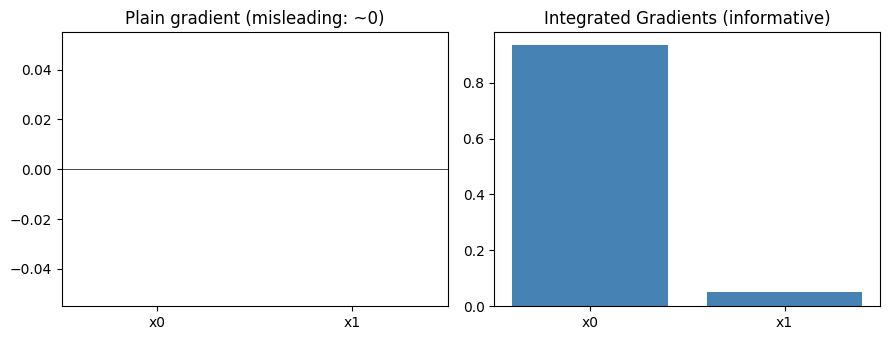

In [9]:
xg = x.clone().unsqueeze(0).requires_grad_(True)
f(xg).backward()
plain = xg.grad.squeeze()

print("plain gradient at x :", [f'{v:+.6f}' for v in plain.tolist()], " <- vanished (saturation)")
print("integrated gradients:", [f'{v:+.6f}' for v in attr.tolist()], " <- recovered the contributions")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].bar(["x0", "x1"], plain.tolist(), color="gray")
ax[0].set_title("Plain gradient (misleading: ~0)")
ax[0].axhline(0, color="k", lw=0.5)
ax[1].bar(["x0", "x1"], attr.tolist(), color="steelblue")
ax[1].set_title("Integrated Gradients (informative)")
ax[1].axhline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

## Step 8 — See the path IG integrates over

IG walks the straight line from the baseline (origin) to $x$ and averages the
gradient of $P(\text{class }1)$ along it. Overlaid on the decision surface, you
can see the path climb out of the class-0 region into the confident class-1
corner — the probability change that climb represents is what gets attributed.

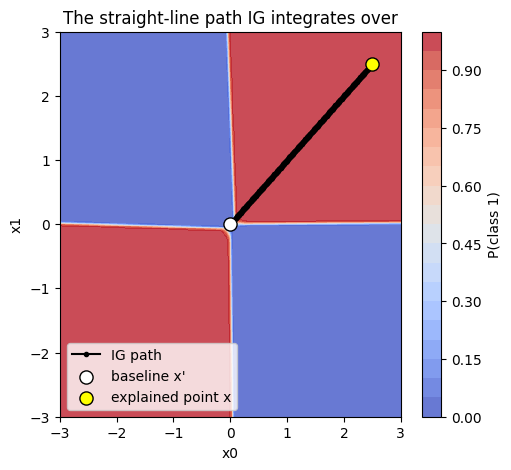

In [10]:
plt.figure(figsize=(5.5, 5))
plt.contourf(gx, gy, prob, levels=20, cmap="coolwarm", alpha=0.8)
plt.colorbar(label="P(class 1)")
plt.plot(path[:, 0], path[:, 1], "k.-", lw=1.5, label="IG path")
plt.scatter([baseline[0]], [baseline[1]], c="white", edgecolors="k", s=90, zorder=5, label="baseline x'")
plt.scatter([x[0]], [x[1]], c="yellow", edgecolors="k", s=90, zorder=5, label="explained point x")
plt.xlabel("x0"); plt.ylabel("x1")
plt.title("The straight-line path IG integrates over")
plt.legend(loc="lower left")
plt.show()

## Things to experiment with

- Explain a **class-0** point like `x = [2.5, -2.5]` (opposite signs). The
  attributions should now be **negative** — those input values pushed the
  probability of class 1 *down*. Completeness still holds.
- Drop `N_STEPS` to 64 and watch the completeness error grow to ~0.1: nonlinear,
  saturating models need a finer Riemann sum than Lesson 1's smooth function.
- Make the network deeper/wider (`Linear(2,32) -> ReLU -> Linear(32,16) -> ReLU
  -> Linear(16,1)`). The IG code doesn't change at all — that's the whole appeal.
- Try `baseline = [-2.5, -2.5]` (the *other* confident class-1 corner). Now both
  ends are class 1, so there's almost no probability to "explain" and the
  attributions collapse toward 0 — a vivid demo of how much the **baseline
  choice** shapes the explanation.
- Change `torch.manual_seed` and re-run: the network learns a different XOR
  solution and the x0/x1 credit split shifts, underlining that attributions are
  a property of the trained model, not the task.

**Next:** `ig_l3` will apply this exact recipe to a real protein language model
(ESM-2), attributing a solubility/function prediction back to individual
amino-acid residues — with the all-zeros (or mask) embedding as the baseline.